<a href="https://colab.research.google.com/github/aayushchourasia123/Machine-Learning/blob/main/Handling%20Missing%20Categorical%20Data/frequent_value_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df=pd.read_csv('/content/housing dataset.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])
df

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [33]:
df.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


Text(0, 0.5, 'number of house')

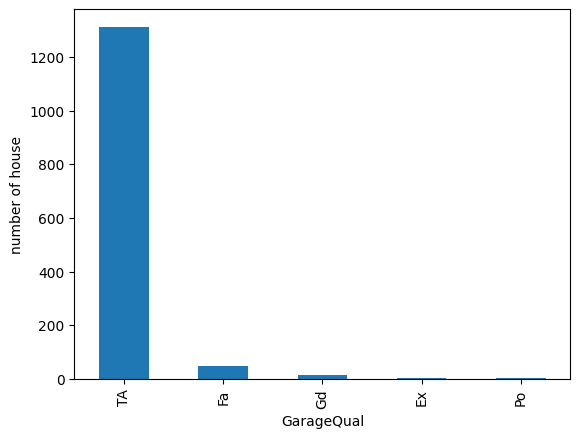

In [34]:
#for GarageQual
df['GarageQual'].value_counts().plot.bar()
plt.ylabel('number of house')

In [35]:
df['GarageQual'].mode()

,GarageQual
0,TA


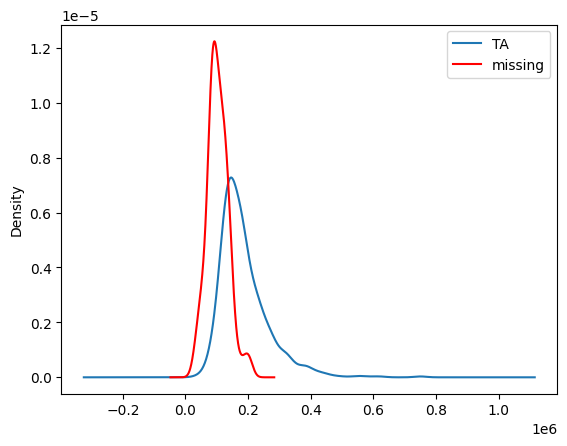

In [36]:
fig=plt.figure()
ax=fig.add_subplot(111)
#distrubution before imputation
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')
plt.legend(['TA','missing'])
plt.show()

In [37]:
temp=df[df['GarageQual']=='TA']['SalePrice']

In [38]:
df.fillna({'GarageQual': 'TA'}, inplace=True)

Text(0, 0.5, 'number of house')

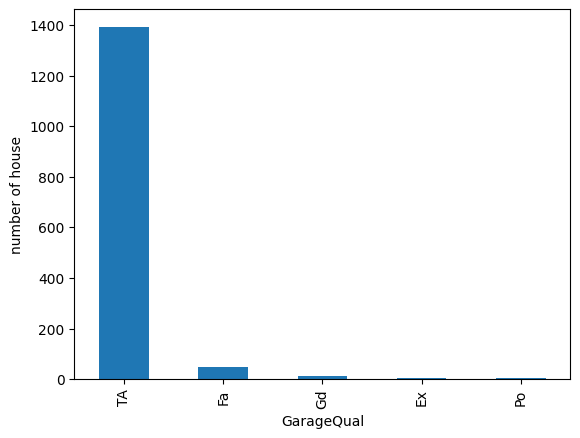

In [39]:
df['GarageQual'].value_counts().plot.bar()
plt.ylabel('number of house')

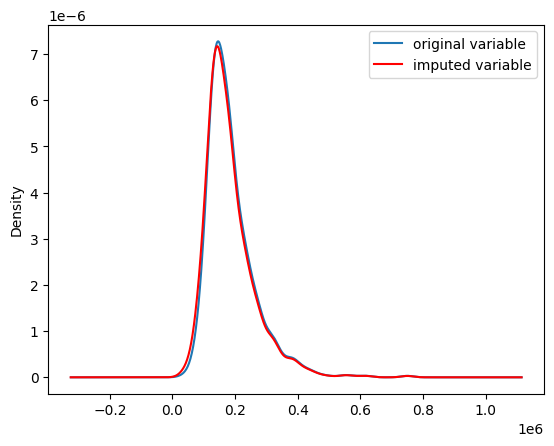

In [40]:
fig=plt.figure()
ax=fig.add_subplot(111)
#distrubution after imputation
temp.plot(kind='kde',ax=ax)
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax,color='red')
plt.legend(['original variable','imputed variable'])
plt.show()

Text(0, 0.5, 'number of house')

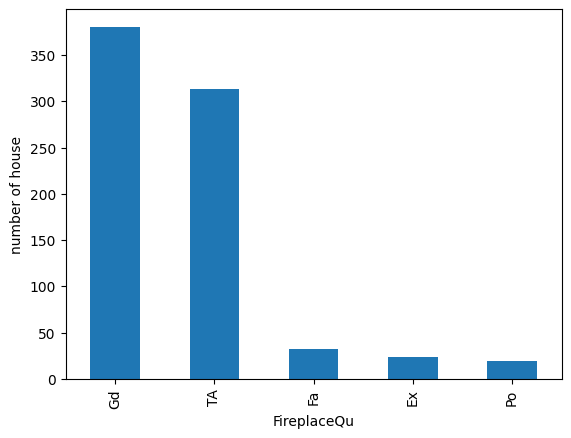

In [41]:
#for fireplace
df['FireplaceQu'].value_counts().plot.bar()
plt.ylabel('number of house')

In [42]:
df['FireplaceQu'].mode()

,FireplaceQu
0,Gd


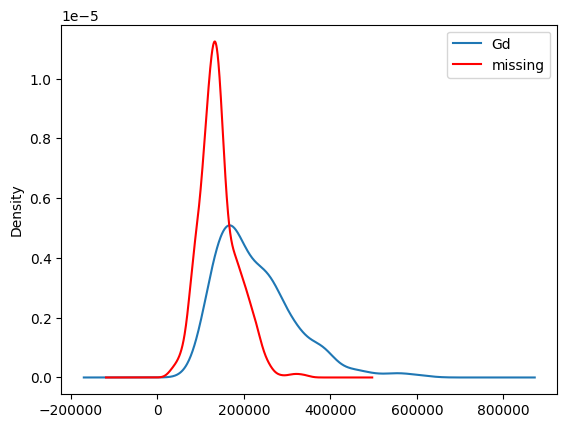

In [43]:
fig=plt.figure()
ax=fig.add_subplot(111)
#distrubution before imputation
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')
plt.legend(['Gd','missing'])
plt.show()

In [44]:
temp=df[df['FireplaceQu']=='Gd']['SalePrice']

In [45]:
df.fillna({'FireplaceQu': 'Gd'}, inplace=True)

Text(0, 0.5, 'number of house')

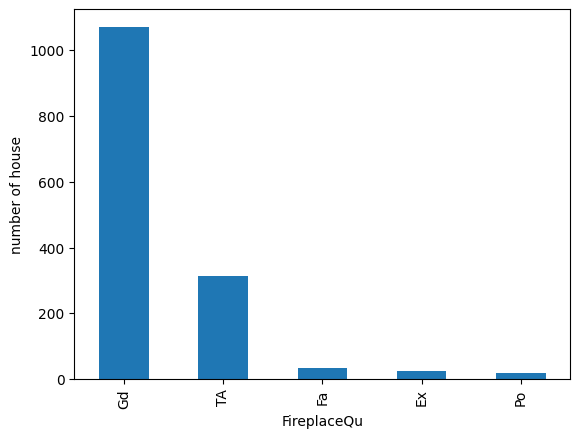

In [46]:
df['FireplaceQu'].value_counts().plot.bar()
plt.ylabel('number of house')

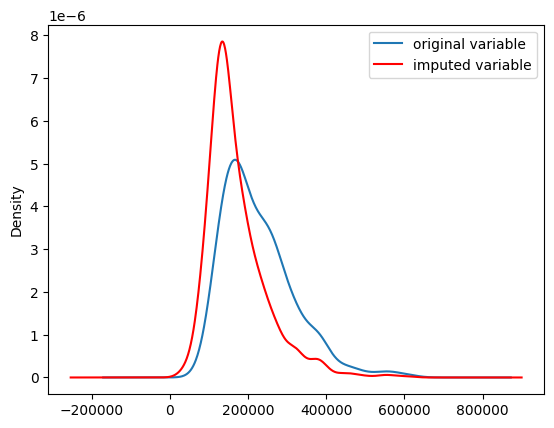

In [47]:
fig=plt.figure()
ax=fig.add_subplot(111)
#distrubution after imputation
temp.plot(kind='kde',ax=ax)
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax,color='red')
plt.legend(['original variable','imputed variable'])
plt.show()

In [48]:
#using sklearn
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2,random_state=0)

In [49]:
from sklearn.impute import SimpleImputer

In [50]:
imputer=SimpleImputer(strategy='most_frequent')

In [51]:
x_train=imputer.fit_transform(x_train)
x_test=imputer.transform(x_test)

In [52]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)